# Nested Sampling for AGN Model Selection

This notebook demonstrates using [blackjax](https://blackjax-devs.github.io/blackjax/) nested sampling with angst's hypercube transformations for Bayesian model selection on AGN light curves.

We compare three models:
1. **Sinusoid only** - periodic signal
2. **DRW only** - Damped Random Walk (stochastic variability)
3. **Sinusoid + DRW** - combined periodic and stochastic

The Bayes factor (ratio of evidences) tells us which model is preferred by the data.

In [1]:
import arviz as az
import jax
import jax.numpy as jnp
import numpy as np
import numpyro.distributions as dist
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
import tempfile

import blackjax
from blackjax.ns.utils import ess, finalise, log_weights, sample

from angst.utils import (
    log_prior_hypercube,
    make_hypercube_model,
    make_log_likelihood_hypercube,
    transform_hypercube_to_original,
)
from angst.analysis import SingleAGNTimeDomain
from angst.dataset import DataSet
from angst.signal import DampedRandomWalk, Sinusoid
from angst.simulation import TimeDomainSim

# For reproducibility
jax.config.update("jax_enable_x64", True)

## 1. Simulate AGN Light Curve Data

We use angst's `TimeDomainSim` to simulate a light curve with **both** a sinusoidal signal and DRW stochastic variability, then see which model the nested sampling prefers.

In [2]:
# Define the TRUE signal used for simulation (Sinusoid + DRW)
# These are the ground truth parameters we'll try to recover

true_sin_amplitude = 0.25  # mag
true_sin_period = 300.0    # days
true_sin_phase = 1.5       # radians

true_drw_amplitude = 0.35  # mag
true_drw_timescale = 200.0 # days

# Create signals with FIXED parameters for simulation
sim_sinusoid = Sinusoid(
    amplitude=true_sin_amplitude,
    period=true_sin_period,
    phase=true_sin_phase,
    name="Sinusoid",
)

sim_drw = DampedRandomWalk(
    amplitude=true_drw_amplitude,
    timescale=true_drw_timescale,
)

# Combined signal for simulation
sim_signal = sim_sinusoid + sim_drw

true_params = {
    "Sinusoid--amplitude": true_sin_amplitude,
    "Sinusoid--period": true_sin_period,
    "Sinusoid--phase": true_sin_phase,
    "DRW--amplitude": true_drw_amplitude,
    "DRW--timescale": true_drw_timescale,
}

print("True simulation parameters:")
for k, v in true_params.items():
    print(f"  {k}: {v}")

True simulation parameters:
  Sinusoid--amplitude: 0.25
  Sinusoid--period: 300.0
  Sinusoid--phase: 1.5
  DRW--amplitude: 0.35
  DRW--timescale: 200.0


In [3]:
# Create the simulation using angst's TimeDomainSim
simulator = TimeDomainSim(
    signals=sim_signal,
    mean_mag=18.0,           # Mean magnitude
    snr=15.0,                # Signal-to-noise ratio
    seed_num=42,             # Random seed for GP realization
    timespan=1500,           # Total observation span in days
    season=(60, 300),        # Observing season (day 60-300 each year)
    cadence=7,               # Average cadence in days
    band="r",                # Photometric band
)

# Simulate and save to temporary file
rng_key = jax.random.key(42)
with tempfile.TemporaryDirectory() as tmpdir:
    save_path = Path(tmpdir) / "sim_data.parquet"
    dset = simulator.simulate(save_path, rng_key, num_agn=1)

print(f"Simulated dataset with {len(dset.agn_ids)} AGN")
print(f"Observations: {len(dset.get_mjds(0, bands=['r']))} points")

Simulated dataset with 1 AGN
Observations: 137 points


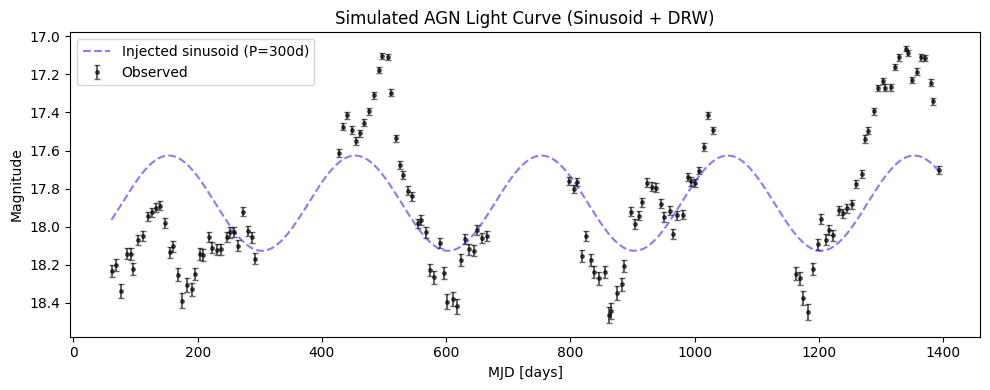

Time span: 1332 days
Mean magnitude: 17.88


In [4]:
# Visualize the simulated data
mjd = dset.get_mjds(0, bands=["r"])
mag = dset.get_lc(0, bands=["r"])
mag_err = dset.get_lc_err(0, bands=["r"])

fig, ax = plt.subplots(figsize=(10, 4))

ax.errorbar(
    mjd, mag, yerr=mag_err,
    fmt=".", color="k", alpha=0.6, label="Observed", markersize=5, capsize=2
)

# Plot the true sinusoid component for reference
t_smooth = jnp.linspace(mjd.min(), mjd.max(), 500)
sin_true = true_sin_amplitude * jnp.sin(2 * jnp.pi / true_sin_period * t_smooth + true_sin_phase) + mag.mean()
ax.plot(t_smooth, sin_true, "b--", alpha=0.5, label=f"Injected sinusoid (P={true_sin_period:.0f}d)", lw=1.5)

ax.set_xlabel("MJD [days]")
ax.set_ylabel("Magnitude")
ax.set_title("Simulated AGN Light Curve (Sinusoid + DRW)")
ax.legend()
ax.invert_yaxis()  # Astronomical convention

plt.tight_layout()
plt.show()

print(f"Time span: {mjd.max() - mjd.min():.0f} days")
print(f"Mean magnitude: {mag.mean():.2f}")

## 2. Define Models for Inference

We'll compare three models with different priors (broad, to be estimated from the data).

In [5]:
# Model 1: Sinusoid only (3 parameters)
# Note: Use math.log/math.pi (Python floats) instead of np.log/np.pi (numpy scalars)
# to avoid equinox "JAX array being set as static" warnings
inf_sinusoid = Sinusoid(
    amplitude=dist.HalfNormal(0.5),
    period=dist.Uniform(100.0, 800.0),
    phase=dist.Uniform(0.0, 2 * np.pi),
    name="Sinusoid",
)

# Model 2: DRW only (2 parameters)
inf_drw = DampedRandomWalk(
    amplitude=dist.LogNormal(np.log(0.3), 0.5),
    timescale=dist.LogNormal(np.log(150.0), 0.5),
)

# Model 3: Sinusoid + DRW (5 parameters)
inf_combined = inf_sinusoid + inf_drw

print("Models defined:")
print(f"  1. Sinusoid only: 3 parameters")
print(f"  2. DRW only: 2 parameters") 
print(f"  3. Sinusoid + DRW: 5 parameters")

Models defined:
  1. Sinusoid only: 3 parameters
  2. DRW only: 2 parameters
  3. Sinusoid + DRW: 5 parameters


/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/src/angst/signal.py:122: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return SignalCollection(signal_list)  # type: ignore[call-arg]


## 3. Nested Sampling Infrastructure

Define the nested sampling runner using blackjax and angst's hypercube transformations.

In [6]:
def run_nested_sampling(
    model,
    model_args,
    model_kwargs,
    rng_key,
    n_live=300,
    delete_fraction=0.3,
    num_inner_steps_multiplier=10,
    convergence_threshold=-3,
    verbose=True,
):
    """
    Run blackjax nested sampling on a NumPyro model.
    
    Uses angst's hypercube transformations to map priors to [0, 1].
    """
    rng_key, init_key, trace_key = jax.random.split(rng_key, 3)

    # Create hypercube-transformed likelihood
    loglikelihood_fn = make_log_likelihood_hypercube(
        model, trace_key, *model_args, **model_kwargs
    )

    # Trace model to get parameter info
    from numpyro.handlers import seed, trace
    hypercube_model = make_hypercube_model(model, trace_key, *model_args, **model_kwargs)
    model_trace = trace(seed(hypercube_model, trace_key)).get_trace(*model_args, **model_kwargs)

    base_params = {
        name: site["value"].shape
        for name, site in model_trace.items()
        if site["type"] == "sample" and name.endswith("_base")
    }
    param_names = list(base_params.keys())
    n_dims = sum(int(jnp.prod(jnp.array(s))) if s else 1 for s in base_params.values())

    if verbose:
        print(f"Model: {n_dims} dimensions, params: {param_names}")

    # Prior sampling (uniform hypercube as dict)
    def sample_prior(key):
        keys = jax.random.split(key, len(base_params))
        return {
            name: jax.random.uniform(k, shape if shape else (), minval=1e-10, maxval=1.0)
            for (name, shape), k in zip(base_params.items(), keys)
        }

    # Setup algorithm
    num_delete = int(n_live * delete_fraction)
    num_inner_steps = num_inner_steps_multiplier * n_dims

    algo = blackjax.nss(
        logprior_fn=log_prior_hypercube,
        loglikelihood_fn=loglikelihood_fn,
        num_delete=num_delete,
        num_inner_steps=num_inner_steps,
    )

    # Initialize
    init_keys = jax.random.split(init_key, n_live)
    initial_particles = jax.vmap(sample_prior)(init_keys)
    state = algo.init(initial_particles)
    step = jax.jit(algo.step)

    # Run
    dead_points = []
    pbar = tqdm(desc="Nested sampling", unit=" pts", disable=not verbose)
    while not (state.logZ_live - state.logZ < convergence_threshold):
        rng_key, subkey = jax.random.split(rng_key)
        state, dead = step(subkey, state)
        dead_points.append(dead)
        pbar.update(num_delete)
        pbar.set_postfix(logZ=f"{state.logZ:.1f}")
    pbar.close()

    # Finalize
    rng_key, weight_key, sample_key = jax.random.split(rng_key, 3)
    final_state = finalise(state, dead_points)

    log_w = log_weights(weight_key, final_state, shape=100)
    logZ_samples = jax.scipy.special.logsumexp(log_w, axis=0)
    logZ_mean, logZ_std = float(logZ_samples.mean()), float(logZ_samples.std())

    n_posterior = min(n_live, 5000)
    posterior_hypercube = sample(sample_key, final_state, shape=n_posterior)
    effective_ss = float(ess(sample_key, final_state))

    # Transform to original space
    rng_key, transform_key = jax.random.split(rng_key)
    transform_keys = jax.random.split(transform_key, n_posterior)
    
    def transform_single(key, samp):
        return transform_hypercube_to_original(model, key, samp, *model_args, **model_kwargs)
    
    posterior = jax.vmap(transform_single)(transform_keys, posterior_hypercube)

    if verbose:
        print(f"Log evidence: {logZ_mean:.2f} ± {logZ_std:.2f}, ESS: {int(effective_ss)}")

    return {
        "logZ_mean": logZ_mean,
        "logZ_std": logZ_std,
        "ess": effective_ss,
        "posterior": posterior,
        "posterior_hypercube": posterior_hypercube,
        "param_names": param_names,
    }

## 4. Create Analysis Objects

Wrap each model with the dataset to create callable NumPyro models.

In [7]:
# Create analysis objects for each model
analysis_sin = SingleAGNTimeDomain(dset=dset, agn_id=0, bands=["r"], signals=inf_sinusoid)
analysis_drw = SingleAGNTimeDomain(dset=dset, agn_id=0, bands=["r"], signals=inf_drw)
analysis_combined = SingleAGNTimeDomain(dset=dset, agn_id=0, bands=["r"], signals=inf_combined)

print(f"Observations: {len(analysis_sin.agn_mjd)}")
print(f"Time span: {analysis_sin.tspan_day:.0f} days")

/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:337: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Observations: 137
Time span: 1332 days


/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/src/angst/analysis.py:779: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  signals if isinstance(signals, SignalCollection) else SignalCollection([signals])
/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:337: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/dave/Dropbox/Documents/research/hazgrav/codes/angst_dev/.venv/lib/python3.13/site-packages/nested_pandas/nestedframe/core.py:337: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

## 5. Run Nested Sampling on Each Model

In [8]:
# Wrapper to make analysis object callable for nested sampling
def make_model(analysis):
    def model(times, lc_err, lc=None):
        return analysis(times, lc_err, lc)
    return model

def get_model_args(analysis):
    return (analysis.agn_mjd, analysis.agn_lc_err), {"lc": analysis.agn_lc_zero_mean}

In [9]:
# Run nested sampling for Sinusoid-only model
print("=" * 50)
print("Model 1: SINUSOID ONLY")
print("=" * 50)

rng_key, ns_key = jax.random.split(rng_key)
args, kwargs = get_model_args(analysis_sin)
results_sin = run_nested_sampling(
    make_model(analysis_sin), args, kwargs, ns_key, n_live=300
)

Model 1: SINUSOID ONLY
Model: 3 dimensions, params: ['Sinusoid--amplitude_base', 'Sinusoid--period_base', 'Sinusoid--phase_base']


Nested sampling: 0 pts [00:00, ? pts/s]

Log evidence: -9206.48 ± 0.27, ESS: 1136


In [10]:
# Run nested sampling for DRW-only model
print("=" * 50)
print("Model 2: DRW ONLY")
print("=" * 50)

rng_key, ns_key = jax.random.split(rng_key)
args, kwargs = get_model_args(analysis_drw)
results_drw = run_nested_sampling(
    make_model(analysis_drw), args, kwargs, ns_key, n_live=300
)

Model 2: DRW ONLY
Model: 2 dimensions, params: ['DRW--amplitude_base', 'DRW--timescale_base']


Nested sampling: 0 pts [00:00, ? pts/s]

Log evidence: 50.25 ± 0.08, ESS: 848


In [11]:
# Run nested sampling for combined model
print("=" * 50)
print("Model 3: SINUSOID + DRW")
print("=" * 50)

rng_key, ns_key = jax.random.split(rng_key)
args, kwargs = get_model_args(analysis_combined)
results_combined = run_nested_sampling(
    make_model(analysis_combined), args, kwargs, ns_key, n_live=300
)

Model 3: SINUSOID + DRW
Model: 5 dimensions, params: ['DRW--amplitude_base', 'DRW--timescale_base', 'Sinusoid--amplitude_base', 'Sinusoid--period_base', 'Sinusoid--phase_base']


Nested sampling: 0 pts [00:00, ? pts/s]

Log evidence: 54.19 ± 0.16, ESS: 1454


## 6. Model Comparison via Bayes Factors

In [12]:
# Collect results
models = {
    "Sinusoid": results_sin,
    "DRW": results_drw,
    "Sin + DRW": results_combined,
}

print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)
print(f"{'Model':<15} {'log Z':>12} {'± err':>10} {'ESS':>8}")
print("-" * 60)
for name, res in models.items():
    print(f"{name:<15} {res['logZ_mean']:>12.2f} {res['logZ_std']:>10.2f} {int(res['ess']):>8}")
print("=" * 60)

MODEL COMPARISON RESULTS
Model                  log Z      ± err      ESS
------------------------------------------------------------
Sinusoid            -9206.48       0.27     1136
DRW                    50.25       0.08      848
Sin + DRW              54.19       0.16     1454


In [13]:
# Compute pairwise Bayes factors
print("\nPAIRWISE BAYES FACTORS")
print("=" * 60)

comparisons = [
    ("Sin + DRW", "DRW"),
    ("Sin + DRW", "Sinusoid"),
    ("DRW", "Sinusoid"),
]

for m1, m2 in comparisons:
    log_bf = models[m1]["logZ_mean"] - models[m2]["logZ_mean"]
    err = jnp.sqrt(models[m1]["logZ_std"]**2 + models[m2]["logZ_std"]**2)
    print(f"\n{m1} vs {m2}:")
    print(f"  log BF = {log_bf:.2f} ± {err:.2f}")


PAIRWISE BAYES FACTORS

Sin + DRW vs DRW:
  log BF = 3.94 ± 0.18

Sin + DRW vs Sinusoid:
  log BF = 9260.67 ± 0.31

DRW vs Sinusoid:
  log BF = 9256.74 ± 0.28


## 7. Posterior Parameter Estimates

In [14]:
def posterior_to_inferencedata(results, model_name=""):
    """Convert nested sampling posterior to arviz InferenceData."""
    posterior = results["posterior"]
    # Convert JAX arrays to numpy and ensure 2D shape (chain, draw)
    posterior_dict = {}
    for name, values in posterior.items():
        arr = np.array(values)
        if arr.ndim == 1:
            arr = arr[np.newaxis, :]  # Add chain dimension
        elif arr.ndim > 2:
            arr = arr.reshape(1, -1)
        posterior_dict[name] = arr
    
    return az.from_dict(posterior=posterior_dict)

# Create InferenceData objects for each model
idata_sin = posterior_to_inferencedata(results_sin, "Sinusoid")
idata_drw = posterior_to_inferencedata(results_drw, "DRW")
idata_combined = posterior_to_inferencedata(results_combined, "Sin+DRW")

In [15]:
# Posterior summaries using arviz
print("Sinusoid Only Model:")
display(az.summary(idata_sin, stat_focus="mean", kind="stats"))

print("\nDRW Only Model:")
display(az.summary(idata_drw, stat_focus="mean", kind="stats"))

print("\nSinusoid + DRW Model:")
display(az.summary(idata_combined, stat_focus="mean", kind="stats"))

Sinusoid Only Model:


,mean,sd,hdi_3%,hdi_97%
Sinusoid--amplitude,0.461,0.003,0.457,0.467
Sinusoid--period,286.054,0.181,285.665,286.342
Sinusoid--phase,0.610,0.015,0.582,0.640



DRW Only Model:


,mean,sd,hdi_3%,hdi_97%
DRW--amplitude,0.333,0.058,0.242,0.437
DRW--timescale,161.652,61.706,89.566,289.076



Sinusoid + DRW Model:


,mean,sd,hdi_3%,hdi_97%
DRW--amplitude,0.278,0.057,0.196,0.369
DRW--timescale,174.539,74.030,74.996,300.823
Sinusoid--amplitude,0.299,0.066,0.185,0.421
Sinusoid--period,294.612,30.906,276.653,311.154
Sinusoid--phase,1.344,1.128,0.041,2.540


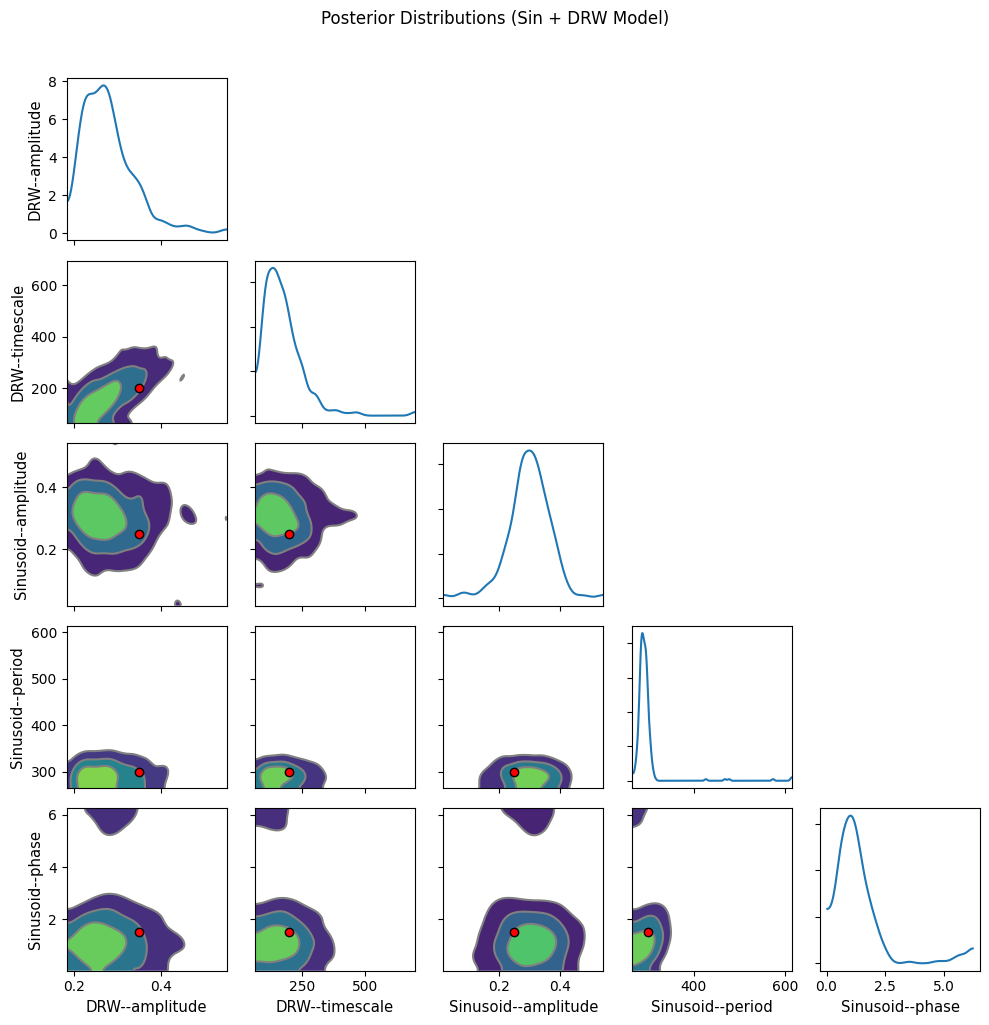

In [27]:
# Pair plot for the combined model using arviz
az.plot_pair(
    idata_combined,
    kind="kde",
    marginals=True,
    reference_values=true_params,
    reference_values_kwargs={"color": "red", "linestyle": "--", "lw": 2},
    figsize=(10, 10),
    textsize=10
)
plt.suptitle("Posterior Distributions (Sin + DRW Model)", y=1.02)
plt.tight_layout()